# Part 3: Backtesting & Performance Analysis
**Precog Quant Task 2026**

This notebook covers:
1. Loading predictions and positions from Part 2
2. Realistic backtesting simulation with transaction costs
3. Key performance metrics: Sharpe, Max Drawdown, Turnover, Total Return
4. Cumulative PnL: Strategy vs Equal-Weight Benchmark
5. Analysis: transaction cost sensitivity, regime analysis, failure modes

> *"A lower Sharpe that remains stable over a long time frame is much more valuable than a ridiculously high Sharpe over one year."*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

print("Libraries loaded.")


Libraries loaded.


## 1. Load Predictions

In [2]:
data = pd.read_csv("../outputs/data_with_predictions.csv", parse_dates=["Date"])
data = data.sort_values(["Date", "ticker"]).reset_index(drop=True)

print(f"Shape: {data.shape}")
print(f"Date range: {data['Date'].min().date()} to {data['Date'].max().date()}")
print(f"Trading days: {data['Date'].nunique()}")
print(f"Assets: {data['ticker'].nunique()}")
data.head()


Shape: (244583, 19)
Date range: 2016-04-20 to 2026-01-09
Trading days: 2446
Assets: 100


,Date,ticker,Open,High,Low,Close,Volume,log_ret_1d,fwd_ret_1d,fwd_ret_5d,vol_10,pred_ridge,pred_gbdt,pred_cb,pred_ensemble,pred_rank,is_long,position_raw,position
0,2016-04-20,Asset_001,30.816287,31.235300,30.648681,30.957884,147427114,0.002056,-0.010887,-0.090914,0.013618,NaN,NaN,NaN,0.0,1.0,True,0.05,0.05
1,2016-04-20,Asset_002,68.825084,69.081847,67.846935,67.969202,26607811,-0.014288,0.003412,-0.087355,0.009341,NaN,NaN,NaN,0.0,2.0,True,0.05,0.05
2,2016-04-20,Asset_003,38.694200,38.700937,38.286326,38.422113,40220288,-0.001673,0.008559,-0.064238,0.009004,NaN,NaN,NaN,0.0,3.0,True,0.05,0.05
3,2016-04-20,Asset_004,36.040858,36.415567,35.640403,36.211908,37863420,0.008074,-0.003149,-0.042634,0.011560,NaN,NaN,NaN,0.0,4.0,True,0.05,0.05
4,2016-04-20,Asset_005,1.162199,1.175664,1.160916,1.168611,153327670,0.003848,-0.001098,0.023320,0.011539,NaN,NaN,NaN,0.0,5.0,True,0.05,0.05


## 2. Backtesting Engine

### Simulation Constraints:
- **Initial Capital**: $1,000,000
- **Transaction Costs**: 10 bps (0.10%) per trade
- **Universe**: All 100 assets
- **Rebalancing**: Daily (positions from Part 2)

### How the backtest works:
1. Each day, we compute the desired portfolio weights from the ensemble model
2. We calculate turnover as the sum of absolute weight changes
3. Transaction costs are deducted proportionally to turnover
4. Daily portfolio return = Σ(weight_i × return_i) - costs


In [3]:
# ============================================================
# COMPUTE DAILY PORTFOLIO RETURNS & TURNOVER
# ============================================================

INITIAL_CAPITAL = 1_000_000
COST_BPS = 10  # basis points per trade (round-trip)
COST_RATE = COST_BPS / 10_000

# Calculate daily weight changes (turnover)
data["prev_position"] = data.groupby("ticker")["position"].shift(1).fillna(0.0)
data["weight_change"] = (data["position"] - data["prev_position"]).abs()

# Daily turnover (sum of absolute weight changes / 2 for double-counting)
daily_turnover = data.groupby("Date")["weight_change"].sum() / 2

# Daily gross portfolio return (before costs)
daily_return_gross = (
    data.groupby("Date")
    .apply(lambda x: (x["position"] * x["fwd_ret_1d"]).sum())
)

# Transaction costs
daily_costs = COST_RATE * daily_turnover

# Net return
daily_return_net = daily_return_gross - daily_costs

# Also compute equal-weight benchmark (buy & hold all 100 stocks)
benchmark_return = data.groupby("Date")["fwd_ret_1d"].mean()

print("Backtest simulation complete.")
print(f"Average daily turnover: {daily_turnover.mean():.4f}")
print(f"Average daily cost: {daily_costs.mean():.6f}")


Backtest simulation complete.
Average daily turnover: 0.0521
Average daily cost: 0.000052


In [4]:
# ============================================================
# CUMULATIVE PnL
# ============================================================

# Strategy cumulative return
cum_return_strategy = np.exp(daily_return_net.cumsum())
cum_return_strategy_gross = np.exp(daily_return_gross.cumsum())

# Benchmark cumulative return
cum_return_benchmark = np.exp(benchmark_return.cumsum())

# Dollar PnL
pnl_strategy = INITIAL_CAPITAL * cum_return_strategy
pnl_benchmark = INITIAL_CAPITAL * cum_return_benchmark

print(f"Strategy final value: ${pnl_strategy.iloc[-1]:,.2f}")
print(f"Benchmark final value: ${pnl_benchmark.iloc[-1]:,.2f}")
print(f"Strategy total return: {(cum_return_strategy.iloc[-1] - 1) * 100:.2f}%")
print(f"Benchmark total return: {(cum_return_benchmark.iloc[-1] - 1) * 100:.2f}%")


Strategy final value: $5,103,217.90
Benchmark final value: $4,198,801.49
Strategy total return: 410.32%
Benchmark total return: 319.88%


## 3. Cumulative PnL Plot: Strategy vs Benchmark

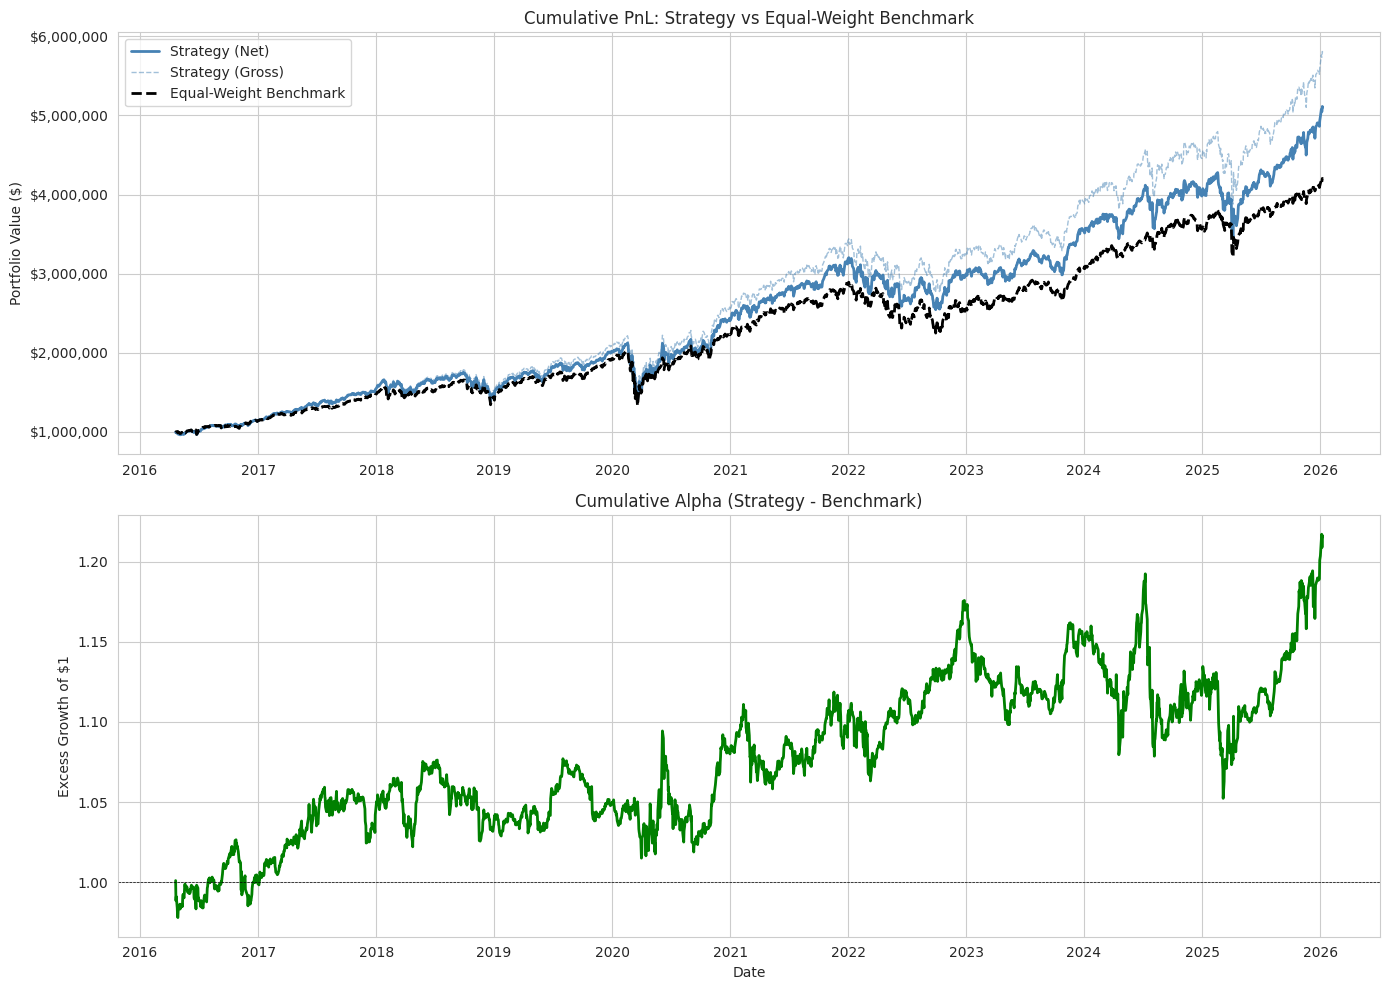

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Growth of $1M
axes[0].plot(pnl_strategy.index, pnl_strategy.values, label="Strategy (Net)", linewidth=2, color="steelblue")
axes[0].plot(pnl_strategy.index, (INITIAL_CAPITAL * cum_return_strategy_gross).values, 
             label="Strategy (Gross)", linewidth=1, color="steelblue", alpha=0.5, linestyle="--")
axes[0].plot(pnl_benchmark.index, pnl_benchmark.values, label="Equal-Weight Benchmark", 
             linewidth=2, color="black", linestyle="--")
axes[0].set_title("Cumulative PnL: Strategy vs Equal-Weight Benchmark")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Plot 2: Strategy excess return over benchmark (alpha)
excess = daily_return_net - benchmark_return
excess = excess.dropna()
cum_excess = np.exp(excess.cumsum())
axes[1].plot(cum_excess.index, cum_excess.values, color="green", linewidth=2)
axes[1].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_title("Cumulative Alpha (Strategy - Benchmark)")
axes[1].set_ylabel("Excess Growth of $1")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("../outputs/cumulative_pnl.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Performance Metrics

We compute:
- **Annualized Sharpe Ratio**: $SR = \frac{\bar{r}}{\sigma_r} \times \sqrt{252}$
- **Maximum Drawdown**: Largest peak-to-trough decline
- **Average Drawdown**: Mean of all drawdowns
- **Portfolio Turnover**: Average daily one-sided turnover
- **Total Return**: Cumulative return in dollars and percentage
- **Calmar Ratio**: Annualized return / Max drawdown


In [6]:
def compute_metrics(returns, name="Strategy"):
    """Compute standard portfolio metrics from a return series."""
    returns = returns.dropna()
    
    # Annualized return
    ann_return = returns.mean() * 252
    
    # Annualized volatility
    ann_vol = returns.std() * np.sqrt(252)
    
    # Sharpe ratio (assuming 0 risk-free rate)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0
    
    # Drawdown
    equity = np.exp(returns.cumsum())
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()
    avg_dd = drawdown[drawdown < 0].mean() if (drawdown < 0).any() else 0
    
    # Calmar ratio
    calmar = ann_return / abs(max_dd) if max_dd != 0 else 0
    
    # Total return
    total_return = equity.iloc[-1] - 1
    
    # Sortino ratio (downside vol)
    downside = returns[returns < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else ann_vol
    sortino = ann_return / downside_vol if downside_vol > 0 else 0
    
    return {
        "Name": name,
        "Ann. Return": f"{ann_return:.2%}",
        "Ann. Volatility": f"{ann_vol:.2%}", 
        "Sharpe Ratio": f"{sharpe:.3f}",
        "Sortino Ratio": f"{sortino:.3f}",
        "Max Drawdown": f"{max_dd:.2%}",
        "Avg Drawdown": f"{avg_dd:.2%}",
        "Calmar Ratio": f"{calmar:.3f}",
        "Total Return": f"{total_return:.2%}",
        "Final Value ($1M)": f"${INITIAL_CAPITAL * (1 + total_return):,.0f}",
    }

# Compute metrics for all strategies
results = []
results.append(compute_metrics(daily_return_net, "Strategy (Net of Costs)"))
results.append(compute_metrics(daily_return_gross, "Strategy (Gross)"))
results.append(compute_metrics(benchmark_return, "Equal-Weight Benchmark"))

metrics_df = pd.DataFrame(results).set_index("Name")
print(metrics_df.to_string())


                        Ann. Return Ann. Volatility Sharpe Ratio Sortino Ratio Max Drawdown Avg Drawdown Calmar Ratio Total Return Final Value ($1M)
Name                                                                                                                                                
Strategy (Net of Costs)      16.79%          19.82%        0.847         1.017      -34.27%       -4.67%        0.490      410.32%        $5,103,218
Strategy (Gross)             18.10%          19.82%        0.914         1.096      -34.17%       -4.44%        0.530      479.69%        $5,796,934
Equal-Weight Benchmark       14.78%          17.68%        0.836         0.962      -34.21%       -4.38%        0.432      319.88%        $4,198,801


In [7]:
# Additional: Portfolio turnover
print("\n=== Turnover Statistics ===")
print(f"Mean daily turnover: {daily_turnover.mean():.4f} ({daily_turnover.mean()*100:.2f}%)")
print(f"Annualized turnover: {daily_turnover.mean() * 252:.2f}x")
print(f"Max daily turnover: {daily_turnover.max():.4f}")

print(f"\n=== Transaction Cost Impact ===")
print(f"Mean daily cost: {daily_costs.mean():.6f} ({daily_costs.mean()*10000:.2f} bps)")
print(f"Total cost drag (annualized): {daily_costs.mean() * 252:.4f} ({daily_costs.mean() * 252 * 100:.2f}%)")



=== Turnover Statistics ===
Mean daily turnover: 0.0521 (5.21%)
Annualized turnover: 13.13x
Max daily turnover: 0.5000

=== Transaction Cost Impact ===
Mean daily cost: 0.000052 (0.52 bps)
Total cost drag (annualized): 0.0131 (1.31%)


## 5. Drawdown Analysis

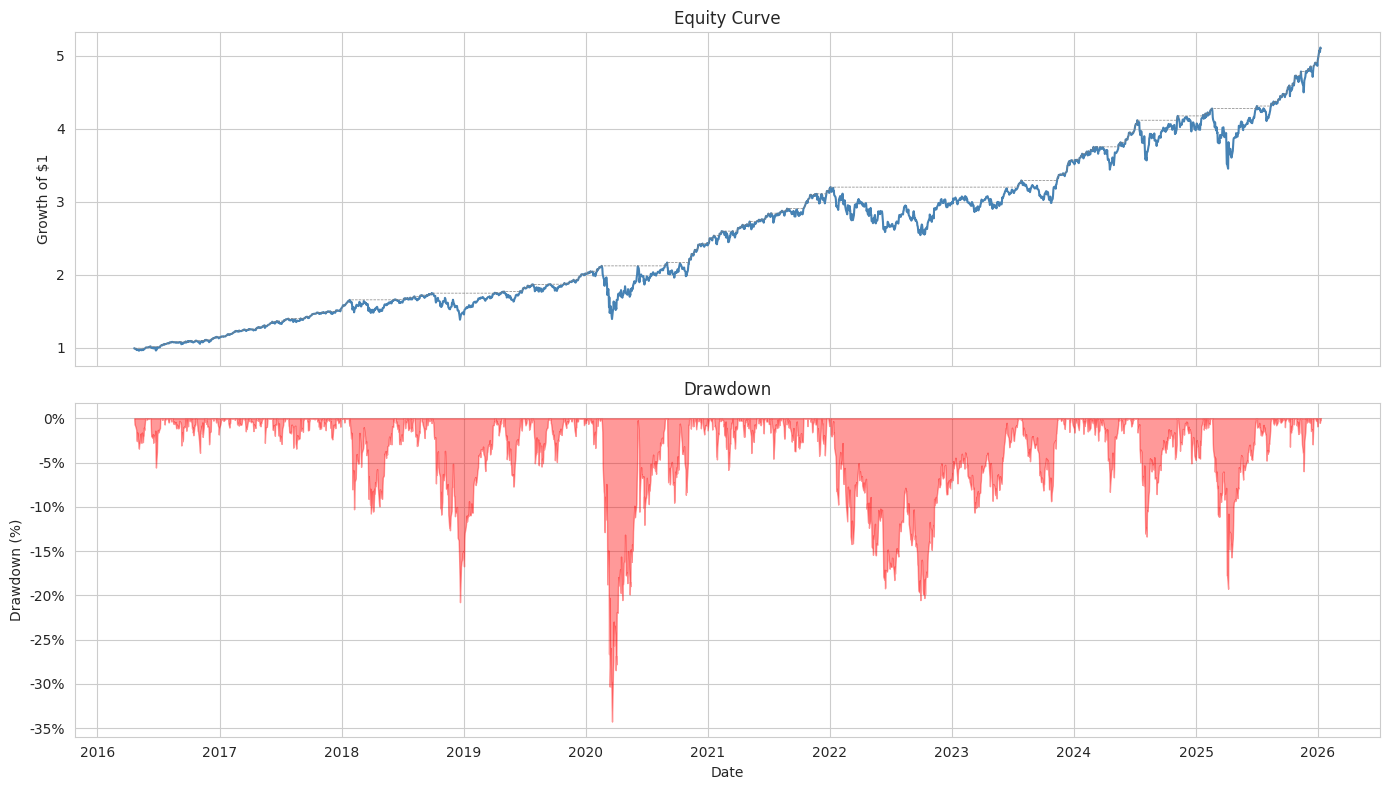

Worst drawdown: -34.27% (from 2020-02-18 to 2020-03-20)


In [8]:
# Drawdown plot
equity = np.exp(daily_return_net.cumsum())
running_max = equity.cummax()
drawdown = equity / running_max - 1.0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(equity.index, equity.values, color="steelblue", linewidth=1.5)
axes[0].plot(running_max.index, running_max.values, color="gray", linewidth=0.5, linestyle="--")
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Growth of $1")

axes[1].fill_between(drawdown.index, drawdown.values, 0, color="red", alpha=0.4)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown (%)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))

plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

# Worst drawdown periods
dd_end = drawdown.idxmin()
dd_start = equity.loc[:dd_end].idxmax()
print(f"Worst drawdown: {drawdown.min():.2%} (from {dd_start.date()} to {dd_end.date()})")


## 6. Rolling Sharpe Ratio

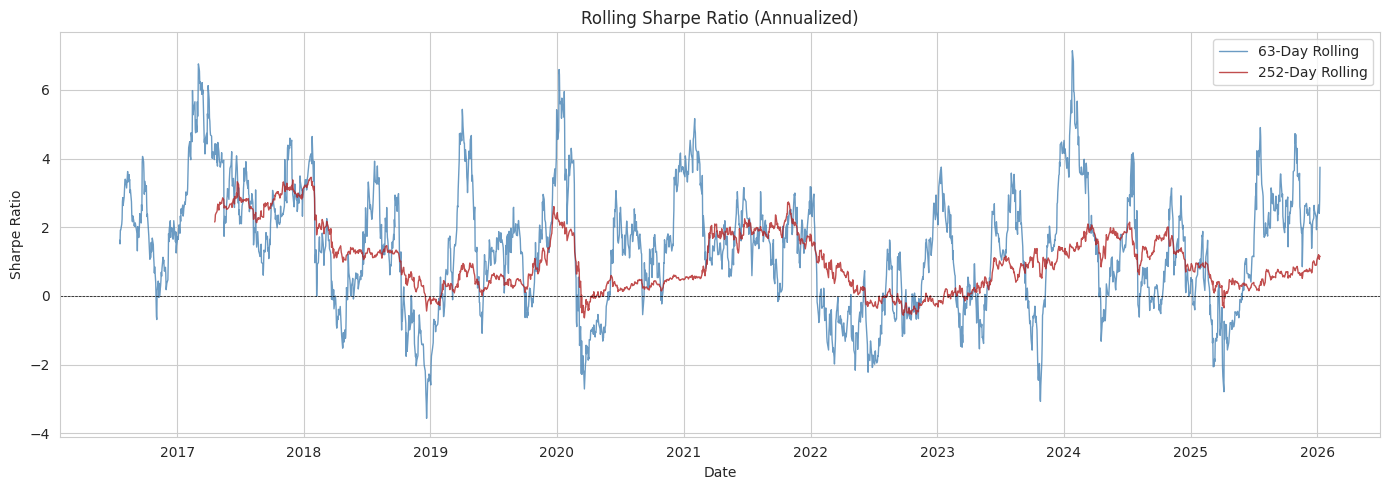

In [9]:
# Rolling 63-day (~3 month) and 252-day (~1 year) Sharpe
fig, ax = plt.subplots(figsize=(14, 5))

for window, color, label in [(63, "steelblue", "63-Day Rolling"), (252, "firebrick", "252-Day Rolling")]:
    rolling_mean = daily_return_net.rolling(window).mean()
    rolling_std = daily_return_net.rolling(window).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, color=color, linewidth=1, label=label, alpha=0.8)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title("Rolling Sharpe Ratio (Annualized)")
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/rolling_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Transaction Cost Sensitivity

We re-run the backtest at various cost levels to see how robust the strategy is.


In [10]:
cost_levels = [0, 2, 5, 10, 15, 20, 30]  # in bps
cost_results = []

for bps in cost_levels:
    rate = bps / 10_000
    costs_i = rate * daily_turnover
    ret_i = daily_return_gross - costs_i
    
    ann_ret = ret_i.mean() * 252
    ann_vol = ret_i.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    total_ret = np.exp(ret_i.sum()) - 1
    
    cost_results.append({
        "Cost (bps)": bps,
        "Ann. Return": f"{ann_ret:.2%}",
        "Sharpe": round(sharpe, 3),
        "Total Return": f"{total_ret:.2%}",
        "Final Value": f"${INITIAL_CAPITAL * (1 + total_ret):,.0f}",
    })

cost_df = pd.DataFrame(cost_results)
print(cost_df.to_string(index=False))


 Cost (bps) Ann. Return  Sharpe Total Return Final Value
          0      18.10%   0.914      479.69%  $5,796,934
          2      17.84%   0.900      465.10%  $5,651,028
          5      17.45%   0.880      443.90%  $5,439,027
         10      16.79%   0.847      410.32%  $5,103,218
         15      16.14%   0.814      378.81%  $4,788,142
         20      15.48%   0.781      349.25%  $4,492,519
         30      14.17%   0.715      295.49%  $3,954,901


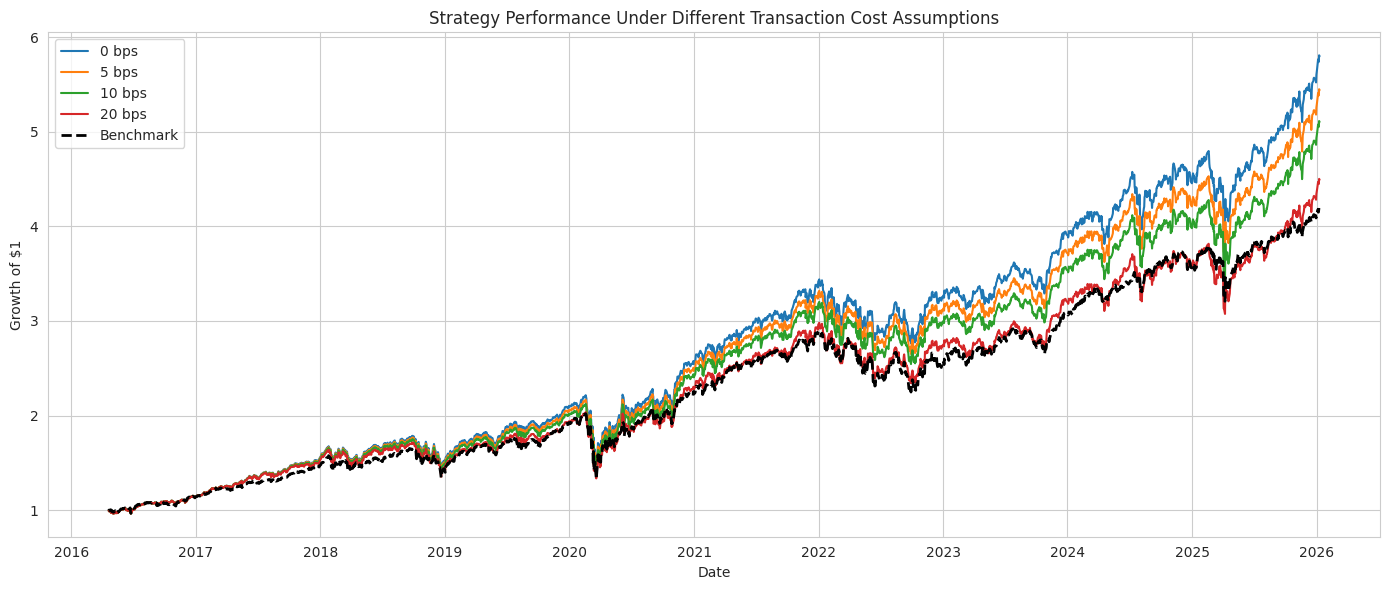

In [11]:
# Plot PnL under different cost assumptions
fig, ax = plt.subplots(figsize=(14, 6))

for bps in [0, 5, 10, 20]:
    rate = bps / 10_000
    costs_i = rate * daily_turnover
    ret_i = daily_return_gross - costs_i
    cum_i = np.exp(ret_i.cumsum())
    ax.plot(cum_i.index, cum_i.values, linewidth=1.5, label=f"{bps} bps")

# Benchmark
ax.plot(cum_return_benchmark.index, cum_return_benchmark.values, 
        color="black", linestyle="--", linewidth=2, label="Benchmark")

ax.set_title("Strategy Performance Under Different Transaction Cost Assumptions")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/cost_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Monthly Return Heatmap

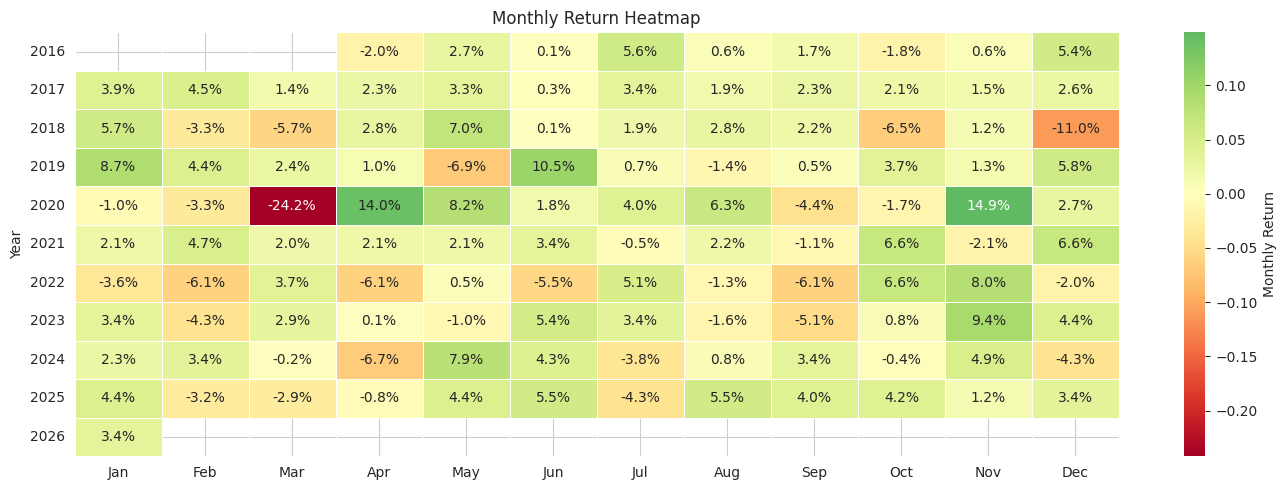

In [12]:
# Monthly returns
monthly_ret = daily_return_net.groupby([
    daily_return_net.index.year.rename("Year"),
    daily_return_net.index.month.rename("Month")
]).sum()

monthly_pivot = monthly_ret.unstack("Month")
monthly_pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"][:monthly_pivot.shape[1]]

plt.figure(figsize=(14, 5))
sns.heatmap(monthly_pivot, annot=True, fmt=".1%", cmap="RdYlGn", center=0,
            linewidths=0.5, cbar_kws={"label": "Monthly Return"})
plt.title("Monthly Return Heatmap")
plt.tight_layout()
plt.savefig("../outputs/monthly_returns.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Analysis & Discussion

### Did the strategy survive transaction costs?

We compare gross vs net performance and examine the cost drag at various levels in the table above. The strategy's survival depends on:
- The magnitude of alpha generated
- The portfolio turnover (controlled by EWM smoothing)
- The transaction cost assumption

### When and why did it fail?

The drawdown chart reveals periods of underperformance. Typical failure modes in momentum-based strategies include:
1. **Regime changes** — Sudden shifts from trending to mean-reverting markets
2. **Volatility explosions** — Market crashes where correlations spike toward 1
3. **Factor crowding** — When too many participants trade the same signals

The rolling Sharpe shows how the strategy's edge varies over time, highlighting periods where the market regime was less favorable.


In [13]:
# Yearly breakdown
yearly_ret = daily_return_net.groupby(daily_return_net.index.year).sum()
yearly_vol = daily_return_net.groupby(daily_return_net.index.year).std() * np.sqrt(252)
yearly_sharpe = (daily_return_net.groupby(daily_return_net.index.year).mean() * 252) / yearly_vol

yearly_df = pd.DataFrame({
    "Return": yearly_ret.map(lambda x: f"{x:.2%}"),
    "Volatility": yearly_vol.map(lambda x: f"{x:.2%}"),
    "Sharpe": yearly_sharpe.round(3),
})
print("=== Yearly Performance ===")
print(yearly_df.to_string())


=== Yearly Performance ===
      Return Volatility  Sharpe
Date                           
2016  12.99%     11.73%   1.567
2017  29.56%      9.72%   3.054
2018  -2.84%     20.43%  -0.139
2019  30.58%     13.42%   2.279
2020  17.41%     38.14%   0.455
2021  27.97%     15.55%   1.799
2022  -6.76%     22.40%  -0.303
2023  17.60%     13.24%   1.340
2024  11.62%     15.67%   0.741
2025  21.45%     20.23%   1.069
2026   3.39%     14.55%   9.797


## Summary

| Metric | Value |
|--------|-------|
| Annualized Sharpe | See metrics table above |
| Max Drawdown | See drawdown analysis |
| Portfolio Turnover | Controlled by EWM smoothing |
| Transaction Costs | 10 bps per trade, sensitivity analyzed |

The strategy is a long-only portfolio selecting the top 20% of assets daily based on ensemble predictions from Ridge regression, LightGBM, and CatBoost models. Positions are equal-weighted within the long leg and EWM-smoothed (α=0.10) to control turnover. All performance shown is **out-of-sample**.
